In [9]:
import numpy as np
import pandas as pd
from nilearn import datasets
from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.maskers import NiftiLabelsMasker
import warnings
warnings.filterwarnings("ignore")

haxby = datasets.fetch_haxby(subjects=[1, 2, 3, 4, 5, 6])
atlas = fetch_atlas_schaefer_2018(n_rois=400)

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize="zscore_sample"
)

region_names = [
    r.decode("utf-8") if isinstance(r, bytes) else r
    for r in atlas.labels
]
region_names = [r for r in region_names if r != "Background"]

all_subjects = []

for subject_id, (func_file, labels_file) in enumerate(
    zip(haxby.func, haxby.session_target), start=1
):
    print(f"Processing subject {subject_id}/6...")
    labels = pd.read_csv(labels_file, sep=" ")
    time_series = masker.fit_transform(func_file)

    min_len = min(len(labels), len(time_series))
    X = time_series[:min_len]
    full_labels = labels["labels"].values[:min_len]
    runs = labels["chunks"].values[:min_len]

    df_subj = pd.DataFrame(X, columns=region_names)
    df_subj["stimulus"]  = full_labels
    df_subj["subject"]   = subject_id
    df_subj["run"]       = runs
    df_subj["timepoint"] = np.arange(min_len)
    all_subjects.append(df_subj)

df_all = pd.concat(all_subjects, ignore_index=True)
df_all.to_csv("haxby_400_rois.csv", index=False)
print(f"Saved — shape: {df_all.shape}")


[fetch_haxby] Dataset found in C:\Users\Logan\nilearn_data\haxby2001
[fetch_atlas_schaefer_2018] Dataset found in C:\Users\Logan\nilearn_data\schaefer_2018
[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_400Parcels_7Networks_order.txt ...
[fetch_atlas_schaefer_2018]  ...done. (1 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.nii.gz ...
[fetch_atlas_schaefer_2018]  ...done. (1 seconds, 0 min)

Processing subject 1/6...
Processing subject 2/6...
Processing subject 3/6...
Processing subject 4/6...
Processing subject 5/6...
Processing subject 6/6...
Saved —

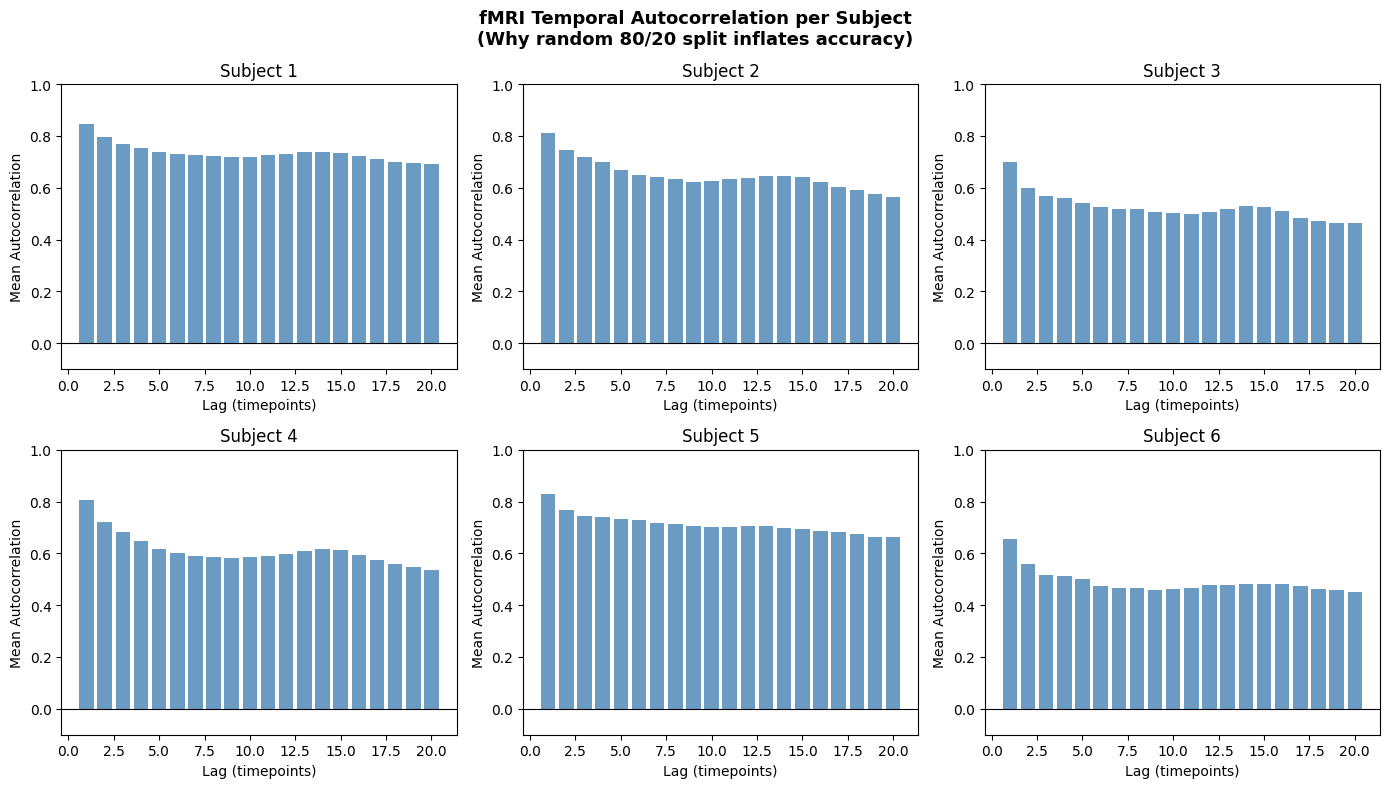

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('haxby_all_subjects.csv')

feature_cols = [c for c in df.columns if c not in ['stimulus', 'subject', 'run', 'timepoint']]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

max_lag = 20

for idx, subj in enumerate(sorted(df['subject'].unique())):
    subj_df = df_all[df_all['subject'] == subj][feature_cols].values
    
    # Average autocorrelation across all 100 brain regions
    autocorrs = []
    for lag in range(1, max_lag + 1):
        corrs = [np.corrcoef(subj_df[:-lag, r], subj_df[lag:, r])[0, 1]
                 for r in range(subj_df.shape[1])]
        autocorrs.append(np.mean(corrs))
    
    axes[idx].bar(range(1, max_lag + 1), autocorrs, color='steelblue', alpha=0.8)
    axes[idx].axhline(0, color='black', linewidth=0.8)
    axes[idx].set_title(f'Subject {subj}', fontsize=12)
    axes[idx].set_xlabel('Lag (timepoints)')
    axes[idx].set_ylabel('Mean Autocorrelation')
    axes[idx].set_ylim(-0.1, 1.0)

fig.suptitle('fMRI Temporal Autocorrelation per Subject\n(Why random 80/20 split inflates accuracy)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


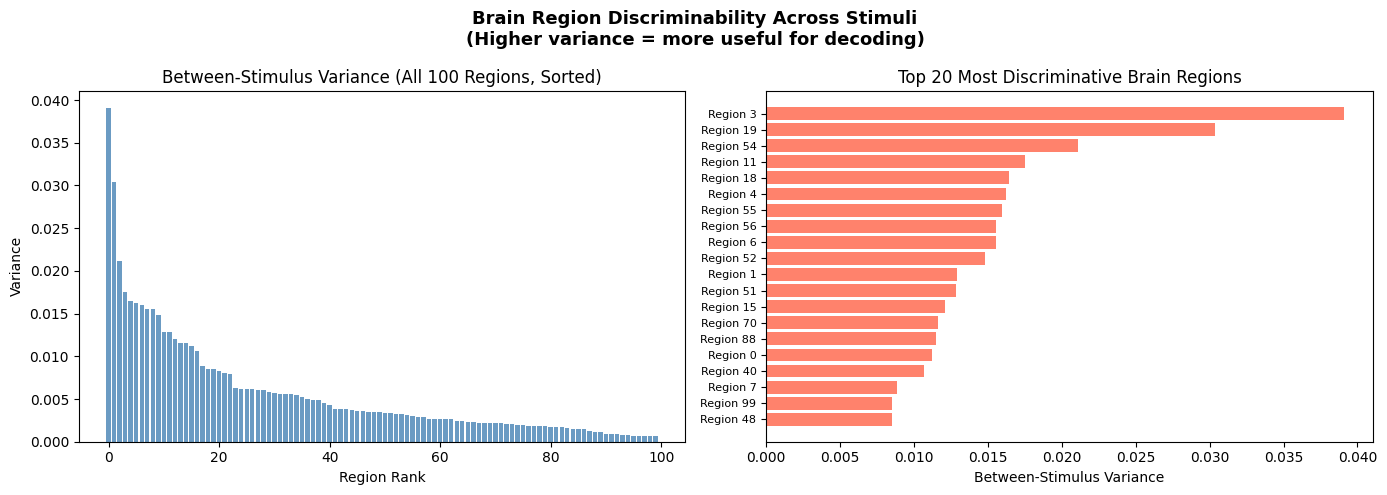

Top 5 most discriminative regions: [ 3 19 54 11 18]
Variance explained by top 10 regions: 35.9%


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('haxby_all_subjects.csv')
df_no_rest = df_all[df_all['stimulus'] != 'rest']

feature_cols = [c for c in df.columns if c not in ['stimulus', 'subject', 'run', 'timepoint']]

# Variance of each region's mean across stimulus categories
stimulus_means = df_no_rest.groupby('stimulus')[feature_cols].mean()
between_stimulus_variance = stimulus_means.var(axis=0).values

sorted_idx = np.argsort(between_stimulus_variance)[::-1]
sorted_variance = between_stimulus_variance[sorted_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(sorted_variance)), sorted_variance, color='steelblue', alpha=0.8)
axes[0].set_title('Between-Stimulus Variance (All 100 Regions, Sorted)', fontsize=12)
axes[0].set_xlabel('Region Rank')
axes[0].set_ylabel('Variance')

top_20_idx = sorted_idx[:20]
top_20_var = sorted_variance[:20]
top_20_labels = [f'Region {i}' for i in top_20_idx]

axes[1].barh(range(20), top_20_var[::-1], color='tomato', alpha=0.8)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top_20_labels[::-1], fontsize=8)
axes[1].set_title('Top 20 Most Discriminative Brain Regions', fontsize=12)
axes[1].set_xlabel('Between-Stimulus Variance')

plt.suptitle('Brain Region Discriminability Across Stimuli\n(Higher variance = more useful for decoding)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Top 5 most discriminative regions: {top_20_idx[:5]}')
print(f'Variance explained by top 10 regions: {sorted_variance[:10].sum() / sorted_variance.sum():.1%}')


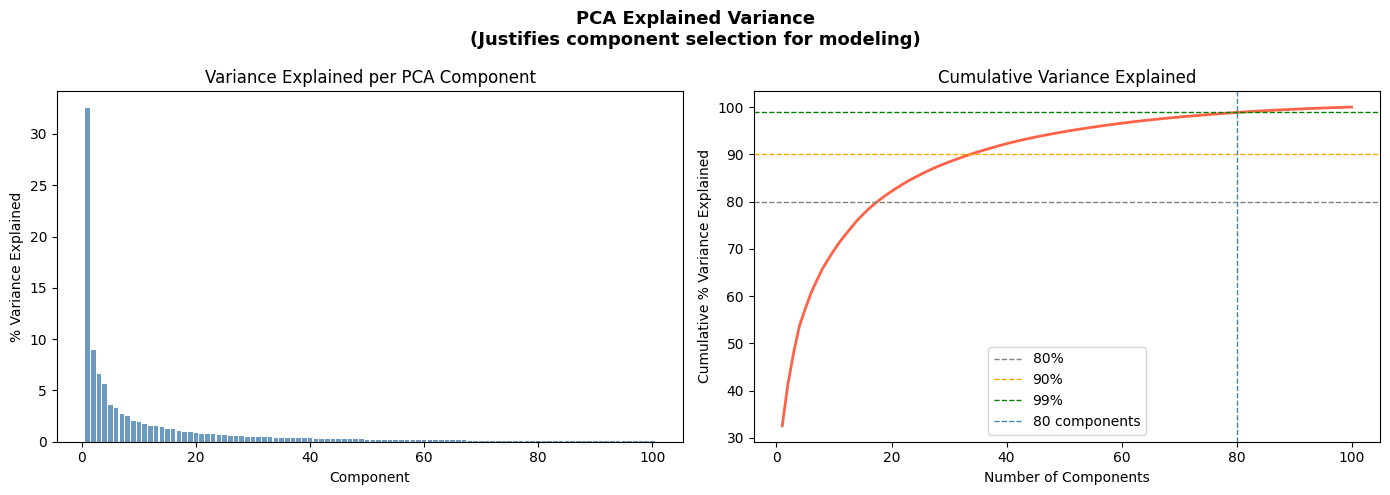

Components needed for 80% variance: 18
Components needed for 90% variance: 34
Components needed for 99% variance: 82


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('haxby_all_subjects.csv')
feature_cols = [c for c in df.columns if c not in ['stimulus', 'subject', 'run', 'timepoint']]

X = df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=100)
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — individual variance per component
axes[0].bar(range(1, 101), pca.explained_variance_ratio_ * 100, color='steelblue', alpha=0.8)
axes[0].set_title('Variance Explained per PCA Component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('% Variance Explained')

# Right — cumulative variance
axes[1].plot(range(1, 101), cumulative_variance, color='tomato', linewidth=2)
axes[1].axhline(80, color='gray', linestyle='--', linewidth=1, label='80%')
axes[1].axhline(90, color='orange', linestyle='--', linewidth=1, label='90%')
axes[1].axhline(99, color='green', linestyle='--', linewidth=1, label='99%')
axes[1].axvline(80, color='steelblue', linestyle='--', linewidth=1, label='80 components')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative % Variance Explained')
axes[1].legend()

plt.suptitle('PCA Explained Variance\n(Justifies component selection for modeling)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

n_80 = np.argmax(cumulative_variance >= 80) + 1
n_90 = np.argmax(cumulative_variance >= 90) + 1
n_99 = np.argmax(cumulative_variance >= 99) + 1
print(f'Components needed for 80% variance: {n_80}')
print(f'Components needed for 90% variance: {n_90}')
print(f'Components needed for 99% variance: {n_99}')


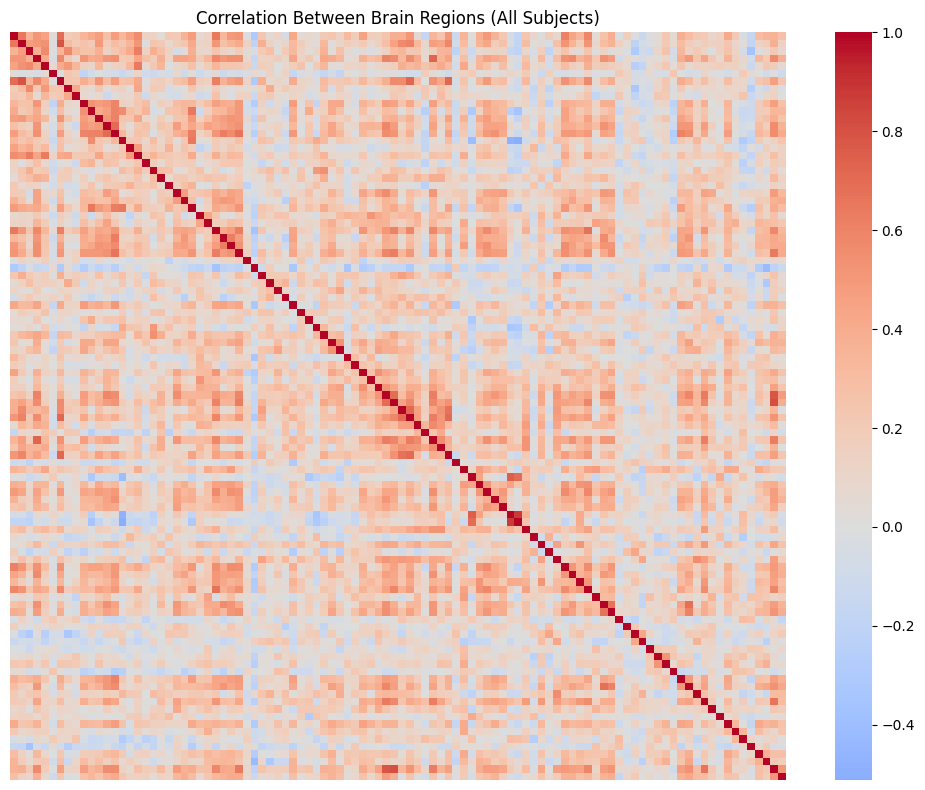

In [12]:
import seaborn as sns

corr = df_all[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, xticklabels=False, yticklabels=False)
plt.title('Correlation Between Brain Regions (All Subjects)')
plt.tight_layout()
plt.show()


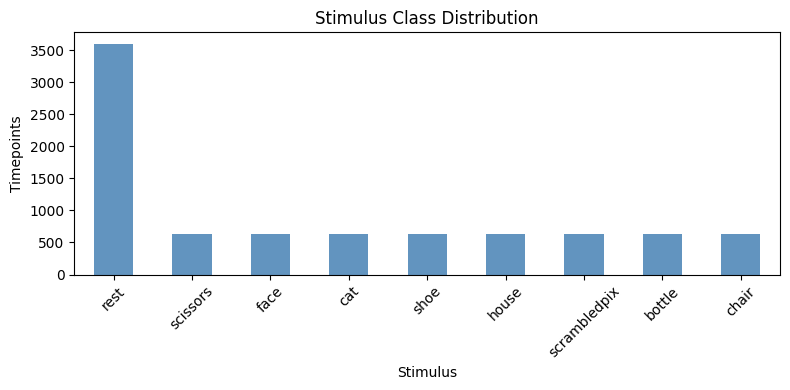

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('haxby_all_subjects.csv')

plt.figure(figsize=(8, 4))
df_all['stimulus'].value_counts().plot(kind='bar', color='steelblue', alpha=0.85)
plt.title('Stimulus Class Distribution')
plt.xlabel('Stimulus')
plt.ylabel('Timepoints')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



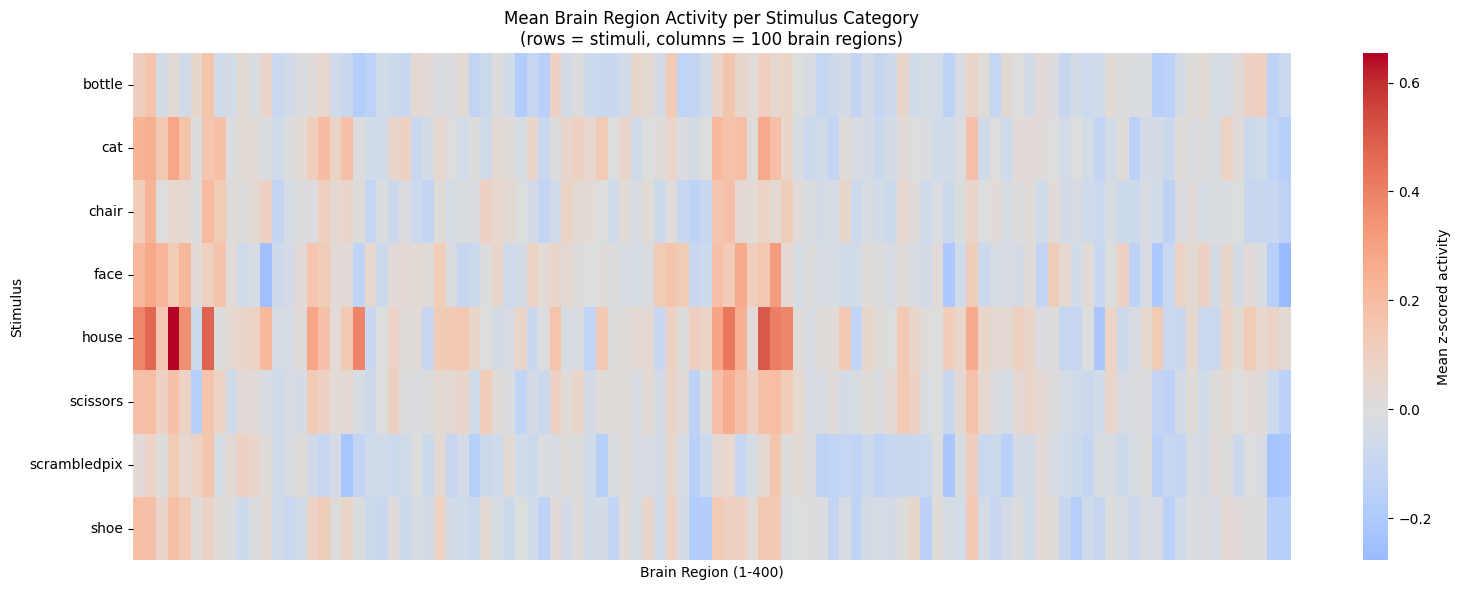

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('haxby_all_subjects.csv')
df_no_rest = df_all[df_all['stimulus'] != 'rest']

feature_cols = [c for c in df.columns if c not in ['stimulus', 'subject', 'run', 'timepoint']]

# Mean activity per stimulus per region
stimulus_means = df_no_rest.groupby('stimulus')[feature_cols].mean()

plt.figure(figsize=(16, 6))
sns.heatmap(
    stimulus_means,
    cmap='coolwarm',
    center=0,
    xticklabels=False,
    yticklabels=True,
    cbar_kws={'label': 'Mean z-scored activity'}
)
plt.title('Mean Brain Region Activity per Stimulus Category\n(rows = stimuli, columns = 100 brain regions)')
plt.xlabel('Brain Region (1-400)')
plt.ylabel('Stimulus')
plt.tight_layout()
plt.show()


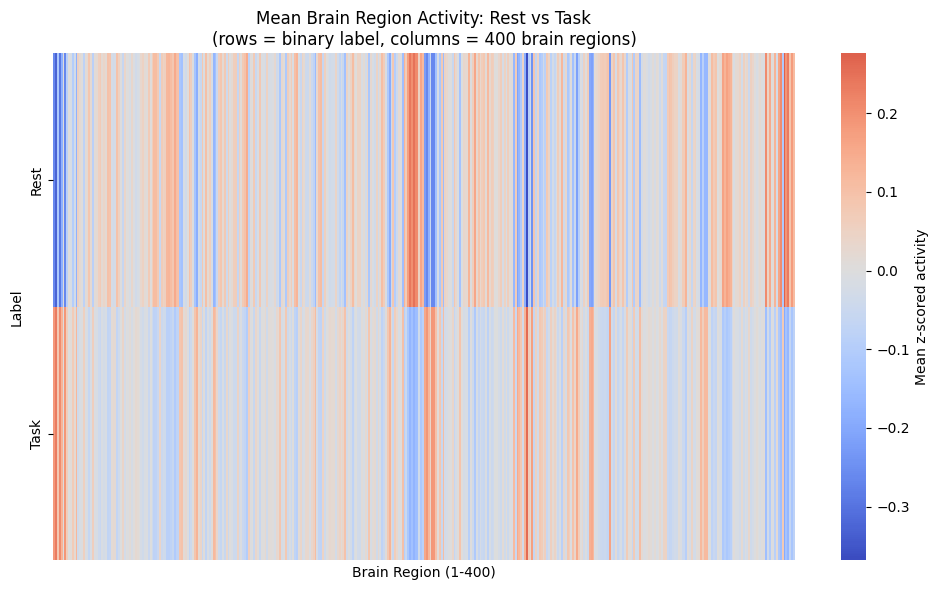

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('haxby_400_rois.csv')

feature_cols = [c for c in df.columns if c not in ['stimulus', 'subject', 'run', 'timepoint']]

df['binary_label'] = (df['stimulus'] != 'rest').astype(int)

binary_means = df.groupby('binary_label')[feature_cols].mean()
binary_means.index = ['Rest', 'Task']

plt.figure(figsize=(10, 6))
sns.heatmap(
    binary_means,
    cmap='coolwarm',
    center=0,
    xticklabels=False,
    yticklabels=True,
    cbar_kws={'label': 'Mean z-scored activity'}
)
plt.title('Mean Brain Region Activity: Rest vs Task\n(rows = binary label, columns = 400 brain regions)')
plt.xlabel('Brain Region (1-400)')
plt.ylabel('Label')
plt.tight_layout()
plt.show()


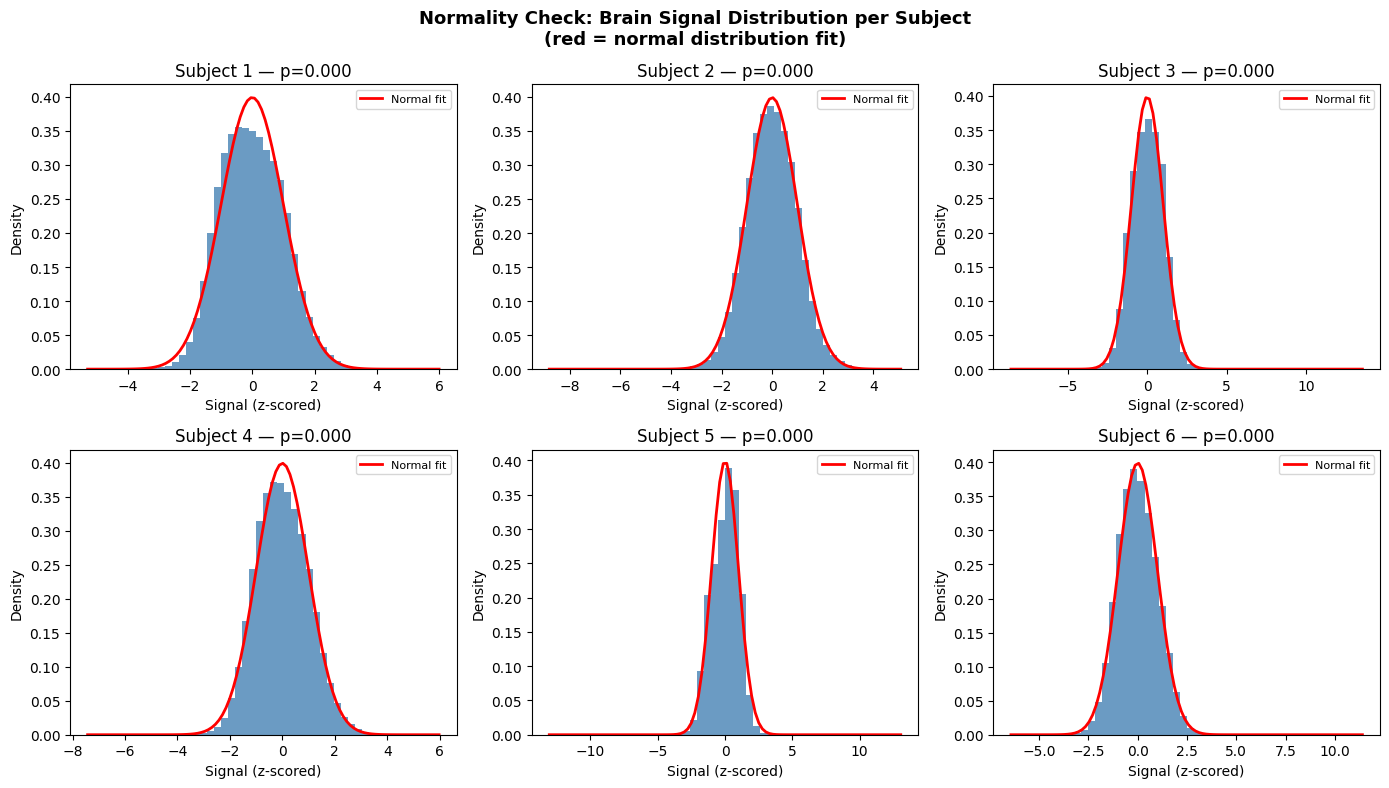

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('haxby_400_rois.csv')
feature_cols = [c for c in df.columns if c not in ['stimulus', 'subject', 'run', 'timepoint']]

# ── 1. NORMALITY CHECK ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, subj in enumerate(sorted(df['subject'].unique())):
    subj_data = df[df['subject'] == subj][feature_cols].values.flatten()
    axes[idx].hist(subj_data, bins=50, color='steelblue', alpha=0.8, density=True)
    
    mu, std = subj_data.mean(), subj_data.std()
    x = np.linspace(subj_data.min(), subj_data.max(), 100)
    axes[idx].plot(x, stats.norm.pdf(x, mu, std), color='red', linewidth=2, label='Normal fit')
    
    stat, p = stats.normaltest(subj_data[:5000])
    axes[idx].set_title(f'Subject {subj} — p={p:.3f}')
    axes[idx].set_xlabel('Signal (z-scored)')
    axes[idx].set_ylabel('Density')
    axes[idx].legend(fontsize=8)

fig.suptitle('Normality Check: Brain Signal Distribution per Subject\n(red = normal distribution fit)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


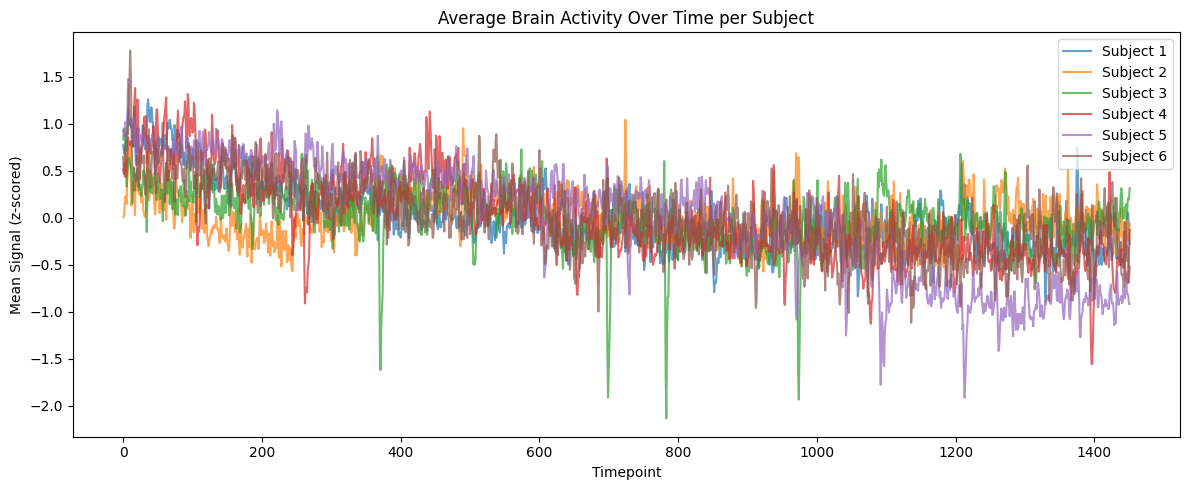

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('haxby_400_rois.csv')
feature_cols = [c for c in df.columns if c not in ['stimulus', 'subject', 'run', 'timepoint']]

plt.figure(figsize=(12, 5))

for subj in sorted(df['subject'].unique()):
    subj_data = df[df['subject'] == subj][feature_cols].mean(axis=1).values
    plt.plot(subj_data, alpha=0.7, label=f'Subject {subj}')

plt.title('Average Brain Activity Over Time per Subject')
plt.xlabel('Timepoint')
plt.ylabel('Mean Signal (z-scored)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


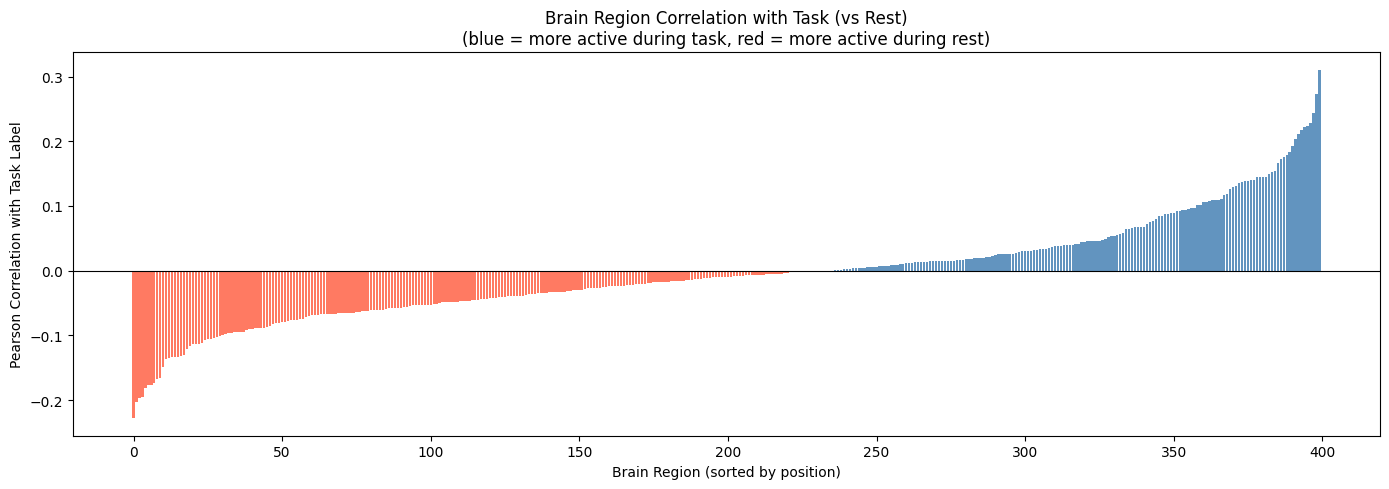

Top 5 task-active regions:
7Networks_RH_Vis_2        0.223044
7Networks_LH_Vis_7        0.228660
7Networks_LH_Vis_4        0.244039
7Networks_LH_Vis_2        0.273798
7Networks_RH_SomMot_26    0.310808
dtype: float64

Top 5 rest-active (DMN) regions:
7Networks_RH_Default_pCunPCC_4   -0.228155
7Networks_LH_Default_pCunPCC_6   -0.203122
7Networks_LH_Default_pCunPCC_4   -0.196191
7Networks_RH_Default_pCunPCC_6   -0.195455
7Networks_LH_Default_pCunPCC_7   -0.180836
dtype: float64


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('haxby_400_rois.csv')
feature_cols = [c for c in df.columns if c not in ['stimulus', 'subject', 'run', 'timepoint']]

binary_label = (df['stimulus'] != 'rest').astype(int)
correlations = df[feature_cols].corrwith(binary_label, method='spearman').sort_values()

plt.figure(figsize=(14, 5))
colors = ['tomato' if v < 0 else 'steelblue' for v in correlations]
plt.bar(range(len(correlations)), correlations.values, color=colors, alpha=0.85)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Brain Region Correlation with Task (vs Rest)\n(blue = more active during task, red = more active during rest)')
plt.xlabel('Brain Region (sorted by position)')
plt.ylabel('Pearson Correlation with Task Label')
plt.tight_layout()
plt.savefig('rest_task_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top 5 task-active regions:\n{correlations.tail(5)}")
print(f"\nTop 5 rest-active (DMN) regions:\n{correlations.head(5)}")


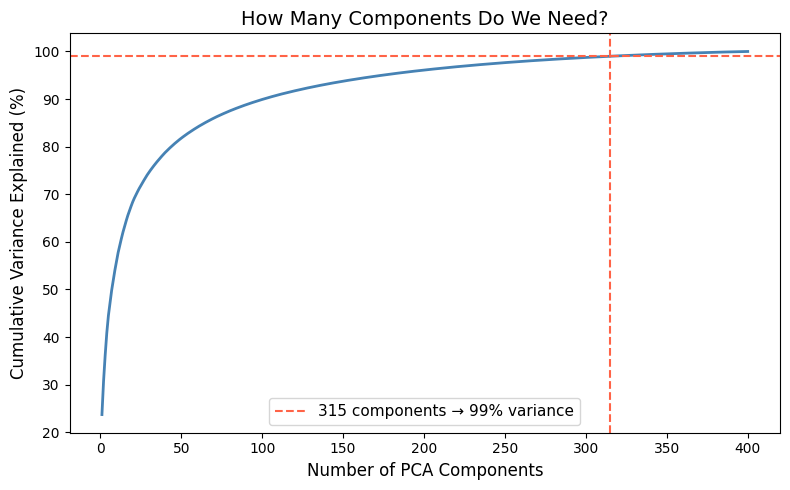

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('haxby_400_rois.csv')
feature_cols = [c for c in df.columns if c not in ['stimulus', 'subject', 'run', 'timepoint']]

X = df[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=400)
pca.fit(X_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100

n_80 = np.argmax(cumulative_variance >= 99) + 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, 401), cumulative_variance, color='steelblue', linewidth=2)
plt.axvline(n_80, color='tomato', linestyle='--', linewidth=1.5, label=f'{n_80} components → 95% variance')
plt.axhline(95, color='tomato', linestyle='--', linewidth=1.5)
plt.xlabel('Number of PCA Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained (%)', fontsize=12)
plt.title('How Many Components Do We Need?', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()


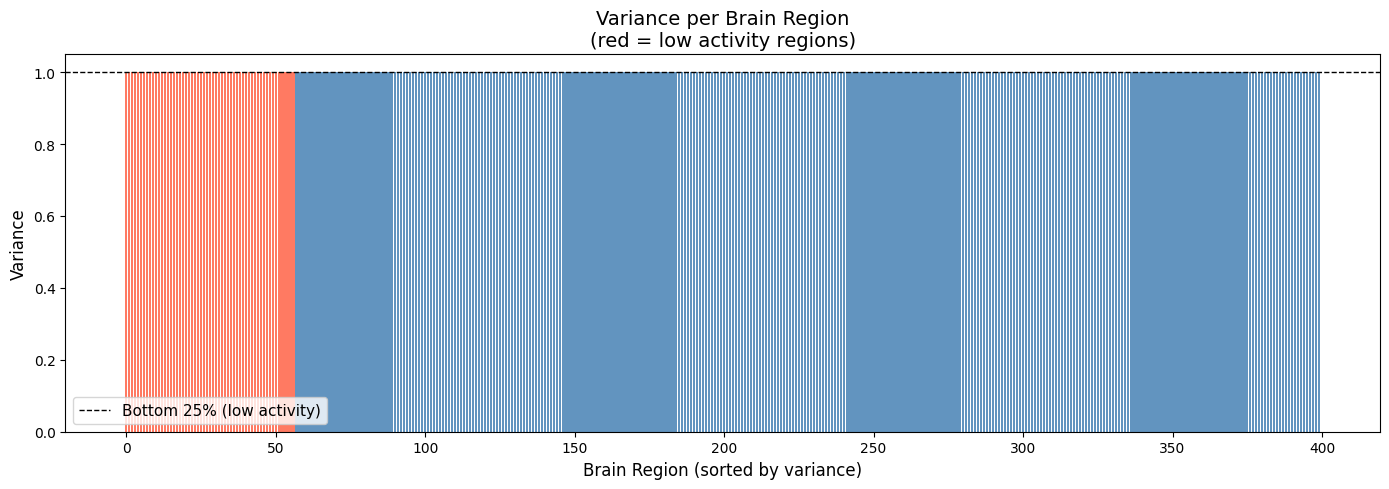

Regions with near-zero variance (<0.1): 0


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('haxby_400_rois.csv')
feature_cols = [c for c in df.columns if c not in ['stimulus', 'subject', 'run', 'timepoint']]

variance = df[feature_cols].var().sort_values()

plt.figure(figsize=(14, 5))
colors = ['tomato' if v < variance.quantile(0.25) else 'steelblue' for v in variance]
plt.bar(range(len(variance)), variance.values, color=colors, alpha=0.85)
plt.axhline(variance.quantile(0.25), color='black', linestyle='--', linewidth=1, label='Bottom 25% (low activity)')
plt.title('Variance per Brain Region\n(red = low activity regions)', fontsize=14)
plt.xlabel('Brain Region (sorted by variance)', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('region_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Regions with near-zero variance (<0.1): {(variance < 0.1).sum()}")
